# Clustering-Based Environmental Intelligence for Forest Restoration Governance

## Objective

This project explores whether countries can be grouped into meaningful socio-environmental typologies using environmental degradation and Indigenous territorial governance indicators.

The analysis combines Global Forest Watch (GFW) and LANDMARK datasets into a unified environmental intelligence dataset. Unsupervised machine learning techniques, including K-Means and hierarchical clustering, are applied to identify latent territorial patterns related to forest loss, carbon emissions, restoration pressure, and Indigenous governance structures.


# Research Question

Can unsupervised machine learning identify meaningful environmental governance typologies between countries based on forest degradation and Indigenous territorial indicators?

# Sub-questions

- Can countries be grouped according to restoration pressure and territorial governance?
- Do countries with higher Indigenous territorial recognition exhibit different environmental profiles?
- Can clustering methods reveal latent socio-environmental patterns in global forest systems?

# Methodological Workflow

1. Data collection from Global Forest Watch and LANDMARK
2. Dataset integration and feature engineering
3. Data preprocessing and scaling
4. PCA dimensionality reduction
5. K-Means clustering experiments
6. Hierarchical clustering comparison
7. Cluster interpretation and environmental analysis

# Data Sources

## 1. Global Forest Watch (GFW)

Global Forest Watch provides environmental indicators related to forest degradation and land-use change.

Variables used:
- tree_cover_loss_ha
- primary_forest_loss_ha
- carbon_gross_emissions_MgCO2e
- extent_2000_ha
- extent_2010_ha
- gain_2000-2012_ha

These variables capture forest degradation intensity, carbon impact, and long-term forest dynamics between 2001 and 2024.

---

## 2. LANDMARK Indigenous Territories Dataset

LANDMARK provides global data about Indigenous and community land rights.

Variables used:
- territories
- recognized
- not_recognized
- area_km2

These indicators represent territorial governance structures and Indigenous land recognition status.

---

## Motivation for Dataset Integration

The project combines ecological degradation indicators with Indigenous territorial governance indicators to explore whether governance structures are associated with different environmental profiles.

The integration creates a unified socio-environmental intelligence dataset suitable for unsupervised learning analysis.

# Dataset Loading

The processed dataset was previously generated by integrating Global Forest Watch and LANDMARK indicators into a unified country-level socio-environmental intelligence dataset.

The dataset is stored locally and loaded into a pandas dataframe for analysis.

In [1]:
import os

os.getcwd()

'C:\\Users\\User\\PycharmProjects\\AISS-forest-restoration-project\\backend\\Fynos-project'

In [2]:
os.listdir()

['Clustering-Based-Intelligence.ipynb', 'data']

# Environment Verification

Before loading the dataset, the notebook environment and working directory were verified to ensure correct file path resolution.

In [3]:
import pandas as pd

df = pd.read_csv("data/country_intelligence_dataset.csv")

print(df.shape)

df.head()

(168, 14)


,country,tree_cover_loss_ha,primary_forest_loss_ha,carbon_gross_emissions_MgCO2e,extent_2000_ha,extent_2010_ha,gain_2000-2012_ha,territories,recognized,not_recognized,area_km2,forest_extent_change_pct,recognition_ratio,restoration_pressure_score
0,Afghanistan,1912,0,3.681470e+05,205771.0,71786.0,10738.0,22.0,0.0,22.0,204.422466,-65.113646,0.0,1.002280
1,Aland,17654,0,4.795715e+06,107739.0,103087.0,2583.0,NaN,NaN,NaN,NaN,-4.317842,NaN,1.022450
2,Albania,47320,0,1.732334e+07,648459.0,588824.0,16468.0,NaN,NaN,NaN,NaN,-9.196418,NaN,1.064643
3,Algeria,231651,0,4.493548e+07,1223325.0,821437.0,89147.0,NaN,NaN,NaN,NaN,-32.852104,NaN,1.276586
4,Angola,4230235,200544,1.497662e+09,55276135.0,53831806.0,1224131.0,NaN,NaN,NaN,NaN,-2.612934,NaN,6.727897


# Data Preprocessing

Before clustering, preprocessing steps were required to ensure comparability between variables.

## Missing Values

Some countries did not contain Indigenous territorial governance information from the LANDMARK dataset. Missing values were replaced with zeros to preserve country observations while indicating absence of governance data.

## Feature Scaling

The environmental indicators operate on very different numerical scales. For example:

- carbon emissions are measured in billions
- restoration pressure values are relatively small
- territorial indicators are measured as counts

Without scaling, variables with large magnitudes would dominate the clustering process. Therefore, standardization was applied using StandardScaler.

In [4]:
# Select clustering features
features = [
    'tree_cover_loss_ha',
    'carbon_gross_emissions_MgCO2e',
    'territories',
    'recognized',
    'not_recognized',
    'recognition_ratio',
    'restoration_pressure_score'
]
# Create working dataframe
X = df[features].fillna(0)
print(X.isnull().sum())

X.head()

tree_cover_loss_ha               0
carbon_gross_emissions_MgCO2e    0
territories                      0
recognized                       0
not_recognized                   0
recognition_ratio                0
restoration_pressure_score       0
dtype: int64


,tree_cover_loss_ha,carbon_gross_emissions_MgCO2e,territories,recognized,not_recognized,recognition_ratio,restoration_pressure_score
0,1912,3.681470e+05,22.0,0.0,22.0,0.0,1.002280
1,17654,4.795715e+06,0.0,0.0,0.0,0.0,1.022450
2,47320,1.732334e+07,0.0,0.0,0.0,0.0,1.064643
3,231651,4.493548e+07,0.0,0.0,0.0,0.0,1.276586
4,4230235,1.497662e+09,0.0,0.0,0.0,0.0,6.727897


## Missing Value Interpretation

Replacing missing governance values with zero does not imply the absence of Indigenous populations. Instead, it indicates that no territorial governance information was available in the integrated dataset for those observations.

This preprocessing decision preserves country-level observations while allowing unsupervised learning methods to operate consistently across the dataset.

## Feature Engineering: Restoration Pressure Score

To support clustering analysis, a composite variable called `restoration_pressure_score` was engineered to summarize environmental restoration urgency across countries.

The indicator combines:
- tree cover loss,
- carbon emissions,
- and forest extent change,

into a single exploratory environmental pressure metric.

The objective was not to create an official environmental index, but rather to generate a simplified indicator that improves interpretation of clustering patterns in socio-environmental governance analysis.

This engineered variable helps identify countries experiencing higher combined environmental pressure and potential restoration urgency.

# Feature Distribution Before Scaling

Before standardization, the variables operated at very different numerical magnitudes.

For example:
- carbon emissions were measured in extremely large values,
- while governance ratios operated on much smaller scales.

Visualizing the distributions before scaling helps justify the need for feature standardization prior to clustering.

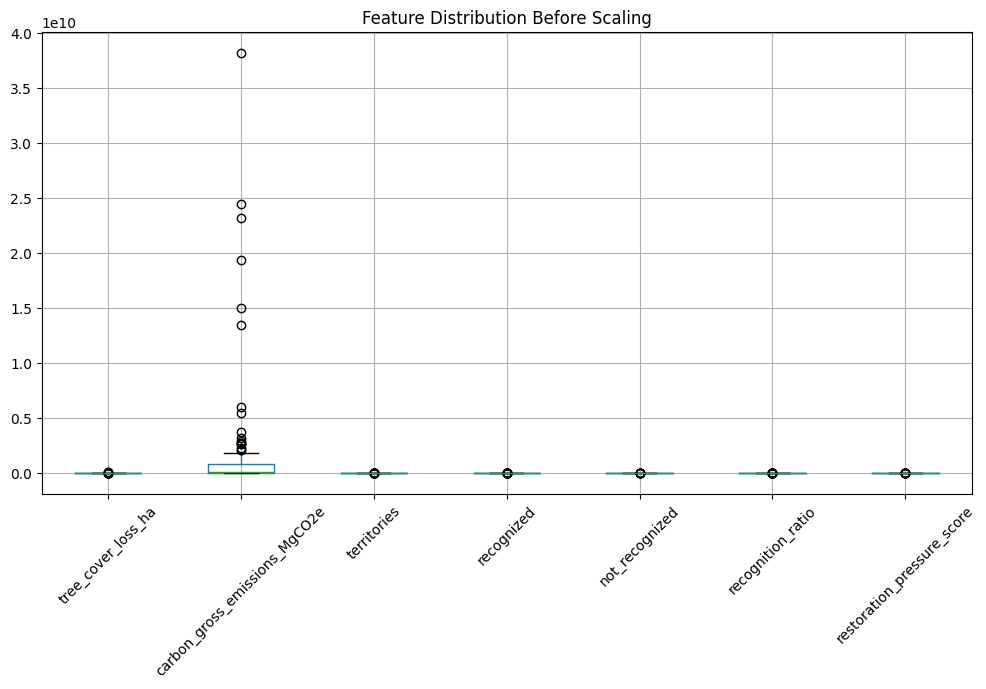

In [5]:
import matplotlib.pyplot as plt

# Visualize raw feature distributions

X.boxplot(figsize=(12,6))

plt.title("Feature Distribution Before Scaling")

plt.xticks(rotation=45)

plt.show()

# Feature Standardization

Because clustering algorithms are distance-based, variables with larger numeric magnitudes can dominate the clustering process.

To avoid this issue, StandardScaler was applied to normalize all variables around:
- mean = 0
- standard deviation = 1

This ensures balanced contribution across environmental and governance indicators during clustering.

In [6]:
from sklearn.preprocessing import StandardScaler
# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

X_scaled[:5]

(168, 7)


array([[-0.2785834 , -0.29558212, -0.16932952, -0.1748844 ,  0.67137182,
        -0.51835678, -0.27678568],
       [-0.27715703, -0.2945799 , -0.17622654, -0.1748844 , -0.17006265,
        -0.51835678, -0.27544805],
       [-0.27446902, -0.29174418, -0.17622654, -0.1748844 , -0.17006265,
        -0.51835678, -0.2726498 ],
       [-0.25776692, -0.28549396, -0.17622654, -0.1748844 , -0.17006265,
        -0.51835678, -0.25859389],
       [ 0.10454181,  0.04334165, -0.17622654, -0.1748844 , -0.17006265,
        -0.51835678,  0.10293299]])

StandardScaler transforms the variables into comparable distributions centered around zero. This prevents large-scale variables from dominating distance calculations during clustering.

A negative value in carbon emissions means the country emits below the global dataset average.

A positive value means the country emits above average relative to other countries.

After scaling, all variables were transformed into standardized values centered around zero. This allows clustering algorithms to compare environmental and governance variables fairly regardless of their original units or magnitudes.

# Feature Distribution After Scaling

After applying StandardScaler, the variables now operate on comparable distributions centered around zero.

This preprocessing step prevents large-scale variables from dominating clustering distance calculations and improves cluster balance.

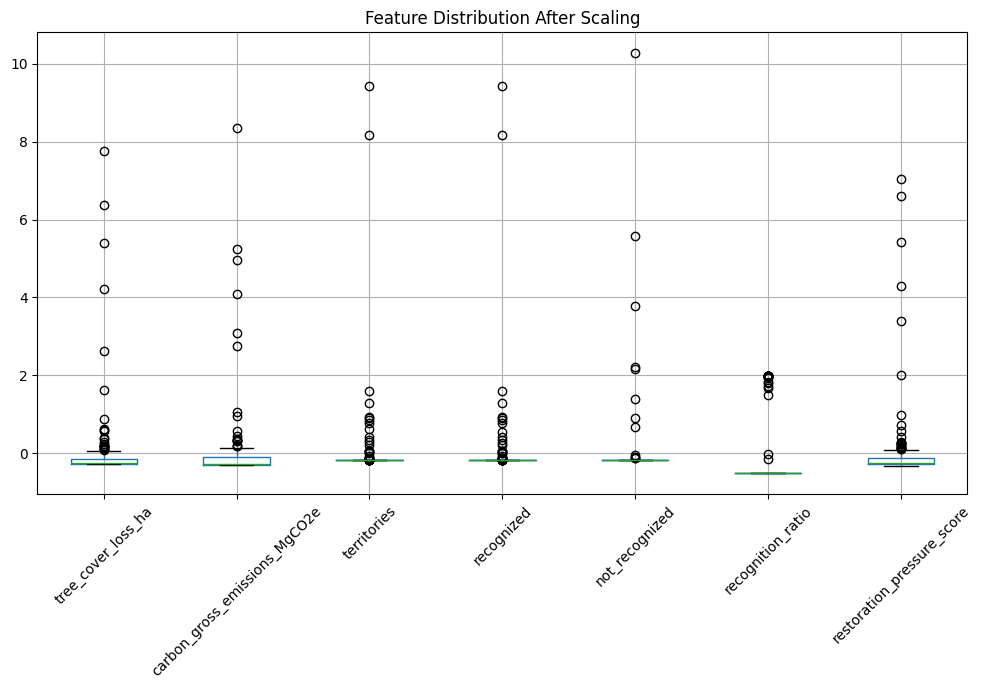

In [7]:
# Convert scaled array back into DataFrame

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

# Visualize scaled distributions

X_scaled_df.boxplot(figsize=(12,6))

plt.title("Feature Distribution After Scaling")

plt.xticks(rotation=45)

plt.show()

After standardization, the variables became comparable in scale, allowing clustering algorithms to evaluate socio-environmental patterns more fairly across countries.

# Principal Component Analysis (PCA)

Principal Component Analysis was applied to reduce dimensionality and visualize clustering structure.

PCA transforms the standardized variables into principal components that capture the largest variance within the dataset.

This allows visualization of multidimensional environmental and governance patterns in a simplified two-dimensional space.

In [8]:
from sklearn.decomposition import PCA
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Explained variance
print(pca.explained_variance_ratio_)

[0.42566514 0.30655125]


PCA reduced the multidimensional dataset into two principal components while preserving most of the variance structure needed for clustering visualization.

the first two components explain 73.3% of the dataset variance.

That is VERY acceptable for clustering visualization.

In [17]:
# PCA DataFrame with country names

pca_df = pd.DataFrame({
    "country": df["country"],
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": clusters
})

pca_df.head(50)

,country,PC1,PC2,Cluster
0,Afghanistan,-0.589320,-0.193020,0
1,Aland,-0.628728,-0.272568,0
2,Albania,-0.624142,-0.273921,0
3,Algeria,-0.603701,-0.280043,0
4,Angola,-0.023374,-0.451681,0
5,Argentina,0.243559,-0.532216,0
6,Australia,1.273772,1.099051,0
7,Austria,-0.556156,-0.293894,0
8,Azerbaijan,-0.629912,-0.272216,0
9,Bangladesh,-0.583887,-0.285716,0


After PCA transformation, each country becomes a point positioned according to its environmental and governance characteristics within reduced-dimensional feature space.

# K-Means Clustering Experiments

K-Means clustering was applied to identify groups of countries sharing similar socio-environmental and governance characteristics.

Multiple values of K were tested to evaluate cluster consistency and structure quality using silhouette scores.

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# Test multiple K values
for k in range(2, 8):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.834
K=3, Silhouette Score=0.856
K=4, Silhouette Score=0.786
K=5, Silhouette Score=0.813
K=6, Silhouette Score=0.817
K=7, Silhouette Score=0.823


# Silhouette Score Evaluation

Silhouette scores were used to compare clustering quality across multiple K values.

Higher silhouette scores indicate:
- stronger separation between clusters,
- and better internal cluster consistency.

This helps identify the most appropriate number of clusters for socio-environmental grouping.

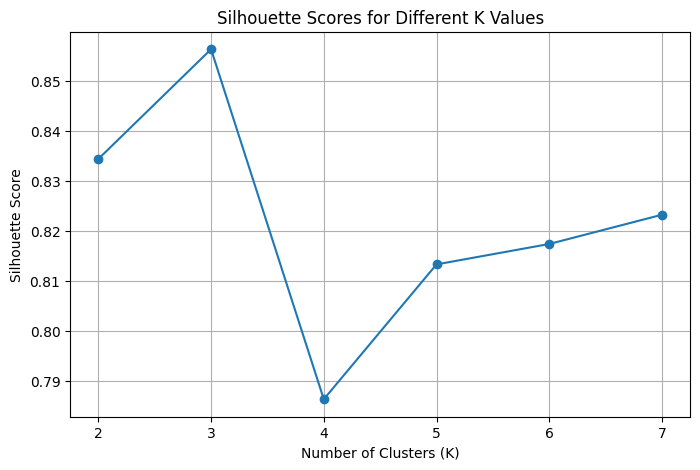

In [11]:
# Store silhouette scores

k_values = []
silhouette_scores = []

for k in range(2, 8):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    k_values.append(k)
    silhouette_scores.append(score)

# Plot results

plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.title("Silhouette Scores for Different K Values")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Silhouette Score")

plt.grid(True)

plt.show()

Silhouette analysis indicated that K=3 produced the strongest cluster separation and internal consistency, suggesting three meaningful socio-environmental governance groups within the dataset.

# Final K-Means Clustering Model

Based on silhouette score evaluation, K=3 was selected as the optimal number of clusters.

The final K-Means model was then applied to group countries into socio-environmental governance clusters.

In [12]:
# Final K-Means model

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Generate cluster labels

clusters = kmeans.fit_predict(X_scaled)

# Add clusters to PCA dataframe

pca_df["Cluster"] = clusters

pca_df.head()

,PC1,PC2,Cluster
0,-0.589320,-0.193020,0
1,-0.628728,-0.272568,0
2,-0.624142,-0.273921,0
3,-0.603701,-0.280043,0
4,-0.023374,-0.451681,0


The final K-Means model assigned each country to one of three socio-environmental governance clusters based on environmental pressure and territorial governance indicators.

In [18]:
# Count countries per cluster

pca_df["Cluster"].value_counts()

Cluster
0    161
2      5
1      2
Name: count, dtype: int64

In [19]:
# View countries inside each cluster

for cluster in sorted(pca_df["Cluster"].unique()):

    print("\n")
    print(f"CLUSTER {cluster}")

    display(
        pca_df[pca_df["Cluster"] == cluster][
            ["country", "PC1", "PC2"]
        ].head(20)
    )



CLUSTER 0


,country,PC1,PC2
0,Afghanistan,-0.589320,-0.193020
1,Aland,-0.628728,-0.272568
2,Albania,-0.624142,-0.273921
3,Algeria,-0.603701,-0.280043
4,Angola,-0.023374,-0.451681
5,Argentina,0.243559,-0.532216
6,Australia,1.273772,1.099051
7,Austria,-0.556156,-0.293894
8,Azerbaijan,-0.629912,-0.272216
9,Bangladesh,-0.583887,-0.285716




CLUSTER 1


,country,PC1,PC2
92,Mexico,3.665816,12.504080
103,New Zealand,2.746361,11.048034




CLUSTER 2


,country,PC1,PC2
18,Brazil,12.454222,-2.457786
25,Canada,9.496409,-0.898357
68,Indonesia,5.867231,-2.171204
122,Russia,9.488255,-3.298485
158,United States,6.768782,-2.457767


The initial clustering primarily separated large global forest powers from the rest of the countries, indicating that forest scale strongly dominates the environmental feature space.

Because the first clustering stage was dominated by very large forest countries, a second clustering analysis was applied to the moderate-pressure group in order to identify more detailed socio-environmental governance patterns.

# Sub-Clustering Moderate-Pressure Countries

The first clustering stage separated very large forest-system countries from the rest of the dataset.

To identify more detailed socio-environmental patterns, a second clustering analysis was applied only to countries belonging to Cluster 0.

In [20]:
# Extract Cluster 0 countries

cluster0_df = pca_df[pca_df["Cluster"] == 0]

print(cluster0_df.shape)

cluster0_df.head()

(161, 4)


,country,PC1,PC2,Cluster
0,Afghanistan,-0.589320,-0.193020,0
1,Aland,-0.628728,-0.272568,0
2,Albania,-0.624142,-0.273921,0
3,Algeria,-0.603701,-0.280043,0
4,Angola,-0.023374,-0.451681,0


The second-stage clustering excluded dominant global forest powers in order to reveal finer socio-environmental governance patterns among moderate-pressure countries.

# Feature Reconstruction for Sub-Clustering

After isolating Cluster 0 countries, the original environmental and governance variables were reconstructed to perform a second-stage clustering analysis.

This ensures that sub-clustering is based on the original socio-environmental indicators rather than only PCA coordinates.

In [21]:
# Extract original variables for Cluster 0 countries
cluster0_original = df[
    df["country"].isin(cluster0_df["country"])
]
# Select features again
features = [
    "tree_cover_loss_ha",
    "carbon_gross_emissions_MgCO2e",
    "territories",
    "recognized",
    "not_recognized",
    "recognition_ratio",
    "restoration_pressure_score"
]
X_cluster0 = cluster0_original[features]
print(X_cluster0.shape)

X_cluster0.head(20)

(161, 7)


,tree_cover_loss_ha,carbon_gross_emissions_MgCO2e,territories,recognized,not_recognized,recognition_ratio,restoration_pressure_score
0,1912,3.681470e+05,22.0,0.0,22.0,0.000000,1.002280
1,17654,4.795715e+06,NaN,NaN,NaN,NaN,1.022450
2,47320,1.732334e+07,NaN,NaN,NaN,NaN,1.064643
3,231651,4.493548e+07,NaN,NaN,NaN,NaN,1.276586
4,4230235,1.497662e+09,NaN,NaN,NaN,NaN,6.727897
5,6968747,1.678739e+09,NaN,NaN,NaN,NaN,9.647486
6,9218341,2.263333e+09,1510.0,1407.0,103.0,0.931788,11.549886
7,439219,2.289758e+08,NaN,NaN,NaN,NaN,1.668195
8,8334,2.464528e+06,NaN,NaN,NaN,NaN,1.010799
9,261746,1.521878e+08,NaN,NaN,NaN,NaN,1.413934


# Handling Missing Governance Values

Many countries do not contain documented indigenous territorial governance information within the integrated dataset.

For clustering purposes, missing governance-related values were replaced with 0 to preserve dataset consistency and allow all countries to remain included in the analysis.

This does not imply the absence of indigenous peoples, but rather the absence of documented governance indicators within the integrated dataset.

In [22]:
# Replace missing values again
X_cluster0 = X_cluster0.fillna(0)
# Verify missing values

X_cluster0.isnull().sum()

tree_cover_loss_ha               0
carbon_gross_emissions_MgCO2e    0
territories                      0
recognized                       0
not_recognized                   0
recognition_ratio                0
restoration_pressure_score       0
dtype: int64

Missing governance values were treated as undocumented indicators rather than evidence of governance absence, but numerical replacement was required to perform clustering analysis consistently.

# Scaling the Sub-Cluster Dataset

After removing dominant global forest outliers, the remaining countries were scaled again using StandardScaler.

This ensures that the second-stage clustering reflects relative variation among moderate-pressure countries rather than being dominated by global-scale forest systems.

In [23]:
from sklearn.preprocessing import StandardScaler

# Scale Cluster 0 data

scaler_cluster0 = StandardScaler()

X_cluster0_scaled = scaler_cluster0.fit_transform(X_cluster0)

# Display scaled values

X_cluster0_scaled[:5]

array([[-0.4825168 , -0.43005473, -0.23093015, -0.25540909,  0.6504068 ,
        -0.49400393, -0.42767539],
       [-0.4765102 , -0.42686594, -0.25933826, -0.25540909, -0.17382965,
        -0.49400393, -0.42251227],
       [-0.46519068, -0.41784338, -0.25933826, -0.25540909, -0.17382965,
        -0.49400393, -0.41171131],
       [-0.39485635, -0.39795677, -0.25933826, -0.25540909, -0.17382965,
        -0.49400393, -0.35745694],
       [ 1.13086484,  0.64831544, -0.25933826, -0.25540909, -0.17382965,
        -0.49400393,  1.03799946]])

The moderate-pressure countries were rescaled independently because removing large global forest powers significantly changed the feature distribution of the dataset.

# PCA for Moderate-Pressure Countries

Principal Component Analysis (PCA) was applied again after removing dominant global forest outliers.

This allows visualization of finer socio-environmental variation among moderate-pressure countries.

In [24]:
from sklearn.decomposition import PCA

# PCA for Cluster 0 countries

pca_cluster0 = PCA(n_components=2)

X_cluster0_pca = pca_cluster0.fit_transform(X_cluster0_scaled)

# Explained variance

print(
    pca_cluster0.explained_variance_ratio_
)

# PCA DataFrame

pca_cluster0_df = pd.DataFrame({
    "country": cluster0_original["country"].values,
    "PC1": X_cluster0_pca[:, 0],
    "PC2": X_cluster0_pca[:, 1]
})

pca_cluster0_df.head(15)

[0.46096273 0.32330394]


,country,PC1,PC2
0,Afghanistan,-0.779335,0.013176
1,Aland,-0.963032,-0.113231
2,Albania,-0.947590,-0.122080
3,Algeria,-0.875769,-0.162894
4,Angola,1.092381,-1.289141
5,Argentina,2.049292,-1.830835
6,Australia,5.432421,1.146596
7,Austria,-0.721411,-0.252009
8,Azerbaijan,-0.967113,-0.110904
9,Bangladesh,-0.814680,-0.198548


After removing dominant global forest powers, the PCA projection revealed clearer separation among moderate-pressure countries and improved interpretability of the environmental governance structure.

# Silhouette Analysis for Moderate-Pressure Countries

A second silhouette analysis was performed after removing dominant global forest outliers to identify the optimal number of subclusters among moderate-pressure countries.

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Test different K values again

for k in range(2, 8):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_cluster0_scaled
    )

    score = silhouette_score(
        X_cluster0_scaled,
        labels
    )

    print(
        f"K={k}, Silhouette Score={score:.3f}"
    )

K=2, Silhouette Score=0.752
K=3, Silhouette Score=0.763
K=4, Silhouette Score=0.695
K=5, Silhouette Score=0.702
K=6, Silhouette Score=0.735
K=7, Silhouette Score=0.718


# Silhouette Visualization for Moderate-Pressure Countries

The silhouette scores were visualized to compare clustering quality across different K values after removing dominant global forest outliers.

The results again indicated that K=3 produced the strongest cluster separation.

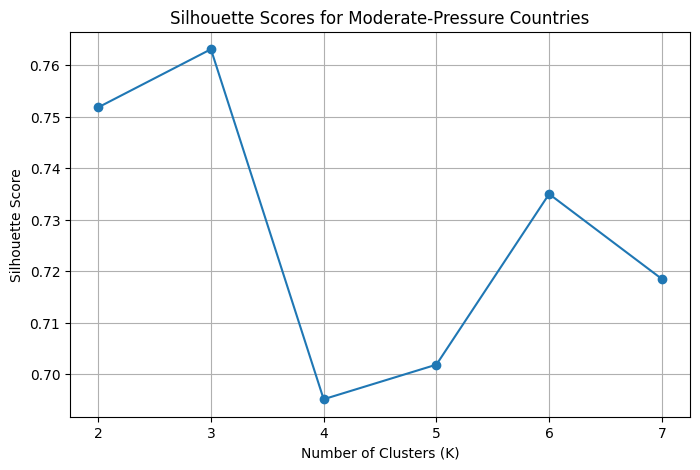

In [26]:
# Store silhouette scores

k_values_cluster0 = []
silhouette_scores_cluster0 = []

for k in range(2, 8):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_cluster0_scaled
    )

    score = silhouette_score(
        X_cluster0_scaled,
        labels
    )

    k_values_cluster0.append(k)
    silhouette_scores_cluster0.append(score)

# Plot silhouette scores

plt.figure(figsize=(8,5))

plt.plot(
    k_values_cluster0,
    silhouette_scores_cluster0,
    marker='o'
)

plt.title(
    "Silhouette Scores for Moderate-Pressure Countries"
)

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Silhouette Score")

plt.grid(True)

plt.show()

The second-stage silhouette analysis again identified K=3 as the optimal clustering configuration, suggesting stable internal structure among moderate-pressure countries.

# Final Subclustering Model

Based on the second silhouette analysis, K=3 was again selected as the optimal clustering configuration for moderate-pressure countries.

The final subclustering model was trained to identify refined socio-environmental governance patterns.

In [28]:
# Final subcluster model

subcluster_model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Generate subcluster labels

subclusters = subcluster_model.fit_predict(
    X_cluster0_scaled
)

# Add labels to dataframe

pca_cluster0_df["Subcluster"] = subclusters

pca_cluster0_df.head(40)

,country,PC1,PC2,Subcluster
0,Afghanistan,-0.779335,0.013176,0
1,Aland,-0.963032,-0.113231,0
2,Albania,-0.947590,-0.122080,0
3,Algeria,-0.875769,-0.162894,0
4,Angola,1.092381,-1.289141,0
5,Argentina,2.049292,-1.830835,0
6,Australia,5.432421,1.146596,2
7,Austria,-0.721411,-0.252009,0
8,Azerbaijan,-0.967113,-0.110904,0
9,Bangladesh,-0.814680,-0.198548,0


# Visualization of Moderate-Pressure Governance Clusters

The refined clustering visualization shows how moderate-pressure countries separate into different socio-environmental governance groups after removing dominant global forest powers.

Countries positioned close together share similar environmental pressure and governance characteristics.

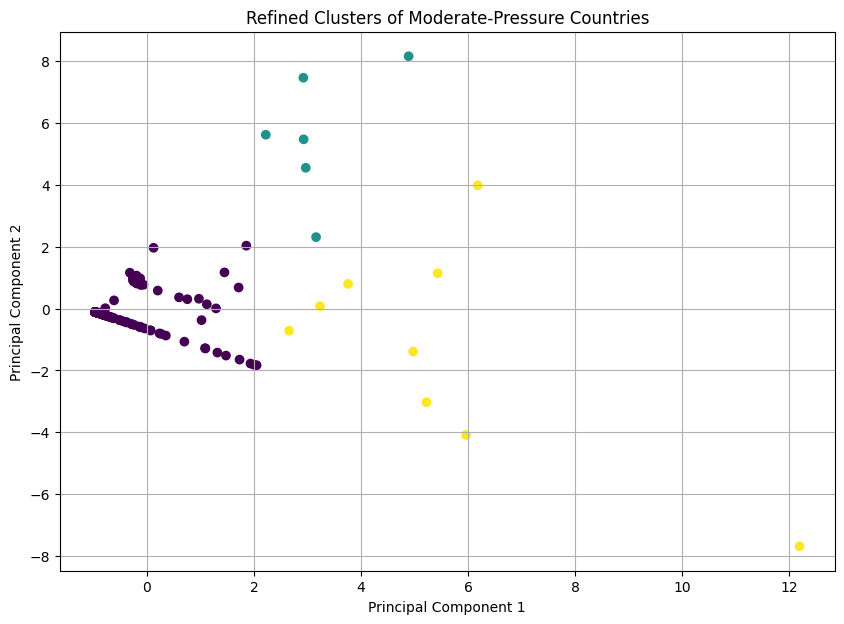

In [29]:
# Visualize refined subclusters

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    pca_cluster0_df["PC1"],
    pca_cluster0_df["PC2"],
    c=pca_cluster0_df["Subcluster"]
)

plt.title(
    "Refined Clusters of Moderate-Pressure Countries"
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.grid(True)

plt.show()

# Interpretation of Refined Governance Clusters

The refined clustering results suggest that moderate-pressure countries can still be separated into distinct socio-environmental governance profiles.

The subclusters appear to reflect:
- different environmental pressure intensities,
- territorial governance structures,
- and restoration-related characteristics.

In [30]:
# Count countries per subcluster

pca_cluster0_df["Subcluster"].value_counts()

Subcluster
0    146
2      9
1      6
Name: count, dtype: int64

In [31]:
# Display countries in each subcluster

for subcluster in sorted(
    pca_cluster0_df["Subcluster"].unique()
):

    print("\n")
    print(f"SUBCLUSTER {subcluster}")

    display(
        pca_cluster0_df[
            pca_cluster0_df["Subcluster"] == subcluster
        ][
            ["country", "PC1", "PC2"]
        ].head(25)
    )



SUBCLUSTER 0


,country,PC1,PC2
0,Afghanistan,-0.779335,0.013176
1,Aland,-0.963032,-0.113231
2,Albania,-0.947590,-0.122080
3,Algeria,-0.875769,-0.162894
4,Angola,1.092381,-1.289141
5,Argentina,2.049292,-1.830835
7,Austria,-0.721411,-0.252009
8,Azerbaijan,-0.967113,-0.110904
9,Bangladesh,-0.814680,-0.198548
10,Belarus,-0.391446,-0.440358




SUBCLUSTER 1


,country,PC1,PC2
26,Chile,2.968297,4.555160
65,India,4.890503,8.163911
68,Ireland,2.923355,7.467761
69,Italy,2.220881,5.623865
93,Mozambique,3.161099,2.312803
132,Spain,2.928330,5.475823




SUBCLUSTER 2


,country,PC1,PC2
6,Australia,5.432421,1.146596
15,Bolivia,4.975329,-1.389118
27,China,5.964632,-4.087313
28,Colombia,3.758874,0.799301
34,Democratic Republic Of The Congo,12.197416,-7.686223
84,Malaysia,5.226741,-3.028115
94,Myanmar,2.656219,-0.714764
109,Paraguay,3.235637,0.080692
110,Peru,6.181182,3.986657


One limitation of the clustering analysis is that governance indicators were only available for a subset of countries within the LandMark dataset. As a result, many countries shared similar governance values after preprocessing, which influenced cluster formation and reduced internal differentiation.

# Cluster Statistics and Interpretation

To better understand the refined governance clusters, summary statistics were computed for each subcluster.

These statistics help identify differences in:
- environmental pressure,
- forest loss intensity,
- carbon emissions,
- and governance structure.

In [32]:
# Attach subcluster labels to original data
cluster0_original["Subcluster"] = subclusters
# Compute cluster statistics
cluster0_stats = cluster0_original.groupby(
    "Subcluster"
)[
    [
        "tree_cover_loss_ha",
        "carbon_gross_emissions_MgCO2e",
        "territories",
        "recognized",
        "recognition_ratio",
        "restoration_pressure_score"
    ]
].mean()

cluster0_stats

,tree_cover_loss_ha,carbon_gross_emissions_MgCO2e,territories,recognized,recognition_ratio,restoration_pressure_score
Subcluster,,,,,,
0,7.365413e+05,3.391642e+08,164.000000,152.304348,0.828414,1.945202
1,1.949914e+06,8.174023e+08,3692.000000,3692.000000,1.000000,2.767316
2,9.407708e+06,4.641497e+09,915.857143,847.571429,0.813737,14.416299


The refined clustering analysis revealed meaningful differences between moderate-pressure countries. One group showed relatively low restoration pressure, another reflected stronger territorial governance structures, while the third contained countries with substantially higher forest loss and carbon emission intensity.

# Cluster Size Distribution

The initial clustering produced highly uneven group sizes.

One dominant cluster contained most countries, suggesting that additional subclustering was necessary to identify finer socio-environmental patterns among moderate-pressure countries.

In [33]:
# Count countries in each initial cluster

cluster_counts = pca_df["Cluster"].value_counts().sort_index()

cluster_counts

Cluster
0    161
1      2
2      5
Name: count, dtype: int64

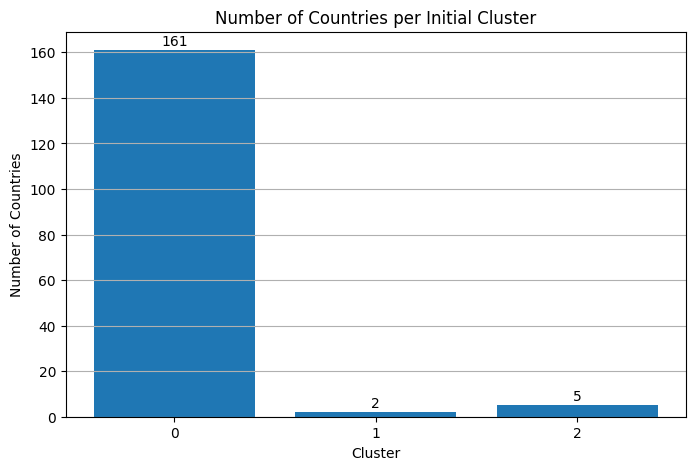

In [35]:
# Improved cluster size visualization

plt.figure(figsize=(8,5))

bars = plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

# Add labels on top

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        str(height),
        ha='center'
    )

plt.title(
    "Number of Countries per Initial Cluster"
)

plt.xlabel("Cluster")

plt.ylabel("Number of Countries")

plt.grid(axis="y")

plt.show()

# Restoration Pressure Across Clusters

Average restoration pressure scores were compared across clusters to evaluate environmental intensity differences between country groups.

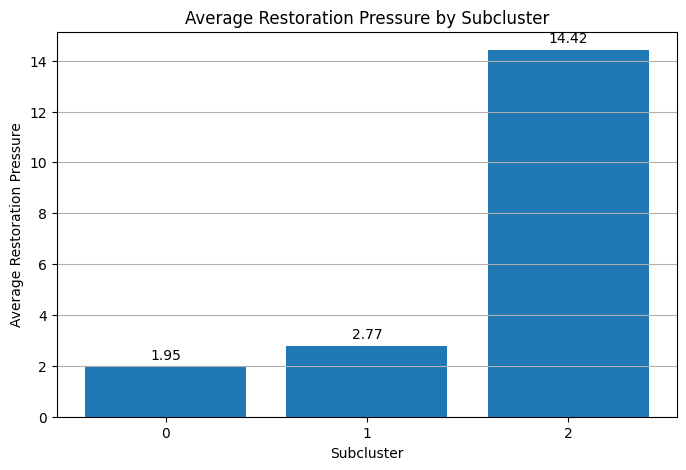

In [36]:
# Restoration pressure per cluster

pressure_by_cluster = cluster0_stats[
    "restoration_pressure_score"
]

plt.figure(figsize=(8,5))

bars = plt.bar(
    pressure_by_cluster.index.astype(str),
    pressure_by_cluster.values
)

# Add value labels

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{height:.2f}",
        ha='center'
    )

plt.title(
    "Average Restoration Pressure by Subcluster"
)

plt.xlabel("Subcluster")

plt.ylabel("Average Restoration Pressure")

plt.grid(axis="y")

plt.show()

The refined clustering analysis revealed three distinct restoration-pressure profiles. Subcluster 0 represented relatively lower-pressure countries, Subcluster 1 reflected governance-intensive systems with moderate pressure, while Subcluster 2 contained countries with substantially higher forest loss and carbon emission intensity, indicating stronger restoration urgency.